## MMTHE01 - Masters Thesis

### E1. Thesis - Apply and Evaluate different XAI methods - Case Study with XGBoost Model
* Applying XAI on a Supervised Learning AI model (XGBoost with SMOTE)
* Applying Model Agnostic Perturbation-based global XAI methods: SP-LIME, NormLIME, Permutation Importance, Adversarial Explanations

#### Importing the libraries

In [1]:
### import general libraries
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
import seaborn as sns
import os
import time
from sklearn.metrics import roc_curve, auc
from sklearn.metrics import recall_score
from sklearn.preprocessing import StandardScaler
from imblearn.over_sampling import SMOTE
import xgboost as xgb
from xgboost import XGBClassifier
import re

from sklearn.preprocessing import LabelEncoder

In [2]:
### Import libraries to save models
import pickle
from tensorflow.keras.models import Model, load_model

In [ ]:
# Fix the random seed so that the same sample is always chosen
np.random.seed(1)

In [3]:
# Check your current working directory
cwd = os.getcwd()

# Build the full path
full_path = r"C:\Users\eaber\Documents\Master Thesis Final\Analysis Files"

# Check if it exists before changing
if os.path.exists(full_path):
    os.chdir(full_path)
    print("Changed directory to:", full_path)
else:
    print("Folder does not exist:", full_path)

Changed directory to: C:\Users\eaber\Documents\Master Thesis Final\Analysis Files


#### Loading the test and train datasets

In [4]:
with open("saved_data/Oversampled_datasets_folder.pkl","rb") as f:
    X_train_np, y_train_np, X_test_np, y_test_np, X_train_scaled_np, X_test_scaled_np = pickle.load(f)

In [5]:
### Import the pickle saved dataset
with open("saved_data/selected_features_final.pkl","rb") as f:
    selected_features_final = pickle.load(f)

In [6]:
if 'default_status' in selected_features_final:
    selected_features_final.remove('default_status')
    
feature_names = [re.sub(r"[ <>+]", "_", c).replace(" ", "_") for c in selected_features_final]

In [7]:
# Convert to dataframe
X_train = pd.DataFrame(X_train_np, columns=feature_names).apply(pd.to_numeric)
X_test = pd.DataFrame(X_test_np, columns=feature_names).apply(pd.to_numeric)
X_train_scaled = pd.DataFrame(X_train_scaled_np, columns=feature_names).apply(pd.to_numeric)

y_train = pd.DataFrame(y_train_np, columns=['default_status'])
y_test = pd.DataFrame(y_test_np, columns=['default_status'])

#### Loading the models

In [8]:
# load XGBoost model
xgb = xgb.XGBClassifier()
xgb.load_model("saved_models/xgb_model_Oversampled.json")

#### Function to combine scores of One Hot Encoded (OHE) features and show original feature names

In [ ]:
original_features = ['title', 'sub_grade', 'issue_year', 'verification_status', 'loan_amnt', 'home_ownership', 'mo_sin_old_il_acct', 'dti', 
                     'acc_open_past_24mths', 'total_il_high_credit_limit', 'issue_month', 'mths_since_recent_inq', 'total_bc_limit', 'purpose',
                     'tot_hi_cred_lim', 'emp_title', 'num_tl_op_past_12m', 'num_bc_tl', 'avg_cur_bal', 'annual_inc', 'num_actv_bc_tl',
                     'percent_bc_gt_75', 'pub_rec_bankruptcies', 'term_in_months', 'mo_sin_rcnt_tl', 'pct_tl_nvr_dlq', 'mo_sin_old_rev_tl_op', 
                     'num_actv_rev_tl', 'num_tl_30dpd', 'earliest_cr_line_year', 'mths_since_recent_bc', 'revol_bal', 'revol_util', 'total_rev_hi_lim', 
                     'inq_last_6mths', 'bc_util', 'num_accts_ever_120_pd', 'earliest_cr_line_month', 'mort_acc', 'bc_open_to_buy', 'num_tl_90g_dpd_24m', 
                     'total_bal_ex_mort', 'num_bc_sats', 'num_il_tl', 'delinq_2yrs', 'num_rev_accts', 'num_op_rev_tl', 'pub_rec', 'initial_list_status',
                     'tax_liens', 'open_acc', 'delinq_amnt', 'total_acc', 'emp_length', 'collections_12_mths_ex_med', 'mo_sin_rcnt_rev_tl_op']

In [ ]:
# Initialize a list to hold aggregated rows
agg_rows = []

In [ ]:
def aggregate_ohe_importances_vectorized(df, feature_col='feature', importance_col='importance'):
    """
    Aggregate one-hot encoded features into their original categorical variable in a vectorized way.

    Parameters:
    -----------
    df : pd.DataFrame
        DataFrame containing feature importances.
    ohe_features : list of str
        List of base feature names that were one-hot encoded.
    feature_col : str
        Column name for feature names.
    importance_col : str
        Column name for signed feature importance values.

    Returns:
    --------
    agg_df : pd.DataFrame
        Aggregated DataFrame with 'feature', 'importance', 'abs_importance', sorted by abs_importance descending.
    """
    
    df = df.copy()
    
    # 1. Replace original columns with base feature name
    for base_col in original_features:
        if base_col == 'title':
            df.loc[df[feature_col].str.startswith(base_col), feature_col] = base_col
        elif base_col == 'pub_rec':
            pattern = r'\b' + re.escape(base_col) + r'\b'
            df[feature_col] = df[feature_col].str.replace(pattern, base_col, regex=True)
        else:
            df[feature_col] = df[feature_col].apply(lambda x: base_col if base_col in x else x)
    
    # 2. Group by feature and sum importance values
    agg_df = df.groupby(feature_col, as_index=False)[importance_col].sum()
    
    # 3. Create absolute importance column
    agg_df['abs_'+importance_col] = agg_df[importance_col].abs()
    
    # 4. Sort by absolute importance descending
    agg_df = agg_df.sort_values(by='abs_'+importance_col, ascending=False).reset_index(drop=True)
    
    return agg_df

### 5 Applying XAI methods to the XGBoost Model

#### 5.4 Applying SHAP (Global Implementation) to the XGBoost Model
* E1B. Thesis - Test different XAI methods with the XGBoost Model (SHAP-Global)

In [9]:
### import
import shap
shap.initjs()

In [10]:
start_time = time.time()

In [11]:
shap_explainer = shap.TreeExplainer(xgb)

In [12]:
shap_values = shap_explainer(X_test)

In [13]:
end_time = time.time()
training_time = end_time - start_time
print(f"SHAP on XGBoost (Explanation Time): {training_time:.2f} seconds")

SHAP on XGBoost (Explanation Time): 13.00 seconds


In [49]:
shap_values.values = np.round(shap_values.values, 3)

In [53]:
shap_df = pd.DataFrame(shap_values.values, columns=X_test.columns)

In [54]:
shap_df.head(1)

,acc_open_past_24mths,annual_inc,avg_cur_bal,bc_open_to_buy,bc_util,collections_12_mths_ex_med,delinq_2yrs,delinq_amnt,dti,earliest_cr_line_month_Apr,...,title,tot_hi_cred_lim,total_acc,total_bal_ex_mort,total_bc_limit,total_il_high_credit_limit,total_rev_hi_lim,verification_status_Not_Verified,verification_status_Source_Verified,verification_status_Verified
0,-0.089,-0.02,0.003,0.006,-0.014,-0.001,-0.012,-0.0,-0.123,-0.0,...,-1.022,0.038,-0.001,0.004,0.008,0.07,0.001,-0.065,-0.001,-0.02


In [63]:
ohe_mapping = {
    'emp_length': ['emp_length_1_year', 'emp_length_10__years', 'emp_length_2_years', 'emp_length_3_years', 'emp_length_4_years', 'emp_length_5_years',	
                   'emp_length_6_years', 'emp_length_7_years', 'emp_length_8_years', 'emp_length_9_years', 'emp_length___1_year'],
    'home_ownership': ['home_ownership_ANY', 'home_ownership_MORTGAGE', 'home_ownership_NONE', 'home_ownership_OTHER', 'home_ownership_OWN',
                       'home_ownership_RENT'],
    'verification_status': ['verification_status_Not_Verified', 'verification_status_Source_Verified', 'verification_status_Verified'],
    'purpose': ['purpose_car', 'purpose_credit_card', 'purpose_debt_consolidation', 'purpose_educational', 'purpose_home_improvement', 'purpose_house',
                'purpose_major_purchase', 'purpose_medical', 'purpose_moving', 'purpose_other', 'purpose_renewable_energy', 'purpose_small_business',
                'purpose_vacation', 'purpose_wedding'],
    'issue_month': ['issue_month_Jan', 'issue_month_Feb', 'issue_month_Mar','issue_month_Apr','issue_month_May', 'issue_month_Jun', 'issue_month_Jul',
                   'issue_month_Aug', 'issue_month_Sep', 'issue_month_Oct', 'issue_month_Nov', 'issue_month_Dec'],
    'earliest_cr_line_month': ['earliest_cr_line_month_Jan', 'earliest_cr_line_month_Feb', 'earliest_cr_line_month_Mar','earliest_cr_line_month_Apr',
                    'earliest_cr_line_month_May', 'earliest_cr_line_month_Jun', 'earliest_cr_line_month_Jul','earliest_cr_line_month_Aug', 
                    'earliest_cr_line_month_Sep', 'earliest_cr_line_month_Oct', 'earliest_cr_line_month_Nov', 'earliest_cr_line_month_Dec'],
    'initial_list_status': ['initial_list_status_f', 'initial_list_status_w']
}

In [64]:
non_ohe_features = ['title', 'sub_grade', 'issue_year',  'loan_amnt', 'mo_sin_old_il_acct', 'dti', 'acc_open_past_24mths', 'total_il_high_credit_limit',
                    'mths_since_recent_inq', 'total_bc_limit', 'tot_hi_cred_lim', 'emp_title', 'num_tl_op_past_12m', 'num_bc_tl', 'avg_cur_bal', 
                    'annual_inc', 'num_actv_bc_tl', 'percent_bc_gt_75', 'pub_rec_bankruptcies', 'term_in_months', 'mo_sin_rcnt_tl', 'pct_tl_nvr_dlq', 
                    'mo_sin_old_rev_tl_op', 'num_actv_rev_tl', 'num_tl_30dpd', 'earliest_cr_line_year', 'mths_since_recent_bc', 'revol_bal', 
                    'revol_util', 'total_rev_hi_lim', 'inq_last_6mths', 'bc_util', 'num_accts_ever_120_pd', 'mort_acc', 'bc_open_to_buy', 
                    'num_tl_90g_dpd_24m',  'total_bal_ex_mort', 'num_bc_sats', 'num_il_tl', 'delinq_2yrs', 'num_rev_accts', 'num_op_rev_tl', 'pub_rec', 
                    'tax_liens', 'open_acc', 'delinq_amnt', 'total_acc', 'collections_12_mths_ex_med', 'mo_sin_rcnt_rev_tl_op']

In [67]:
for non_ohe_value in non_ohe_features:
    ohe_mapping[non_ohe_value] = [non_ohe_value]

In [69]:
#ohe_mapping

In [70]:
# Aggregate by summing absolute SHAP contributions of OHE columns
agg_shap_dict = {}
for feature, cols in ohe_mapping.items():
    agg_shap_dict[feature] = shap_df[cols].sum(axis=1)  # sum across one-hot columns

In [72]:
# Convert to DataFrame
agg_shap_df = pd.DataFrame(agg_shap_dict)
agg_shap_df.head(1)

,emp_length,home_ownership,verification_status,purpose,issue_month,earliest_cr_line_month,initial_list_status,title,sub_grade,issue_year,...,delinq_2yrs,num_rev_accts,num_op_rev_tl,pub_rec,tax_liens,open_acc,delinq_amnt,total_acc,collections_12_mths_ex_med,mo_sin_rcnt_rev_tl_op
0,0.002,0.064,-0.086,-0.038,0.173,0.004,0.0,-1.022,-0.86,-1.331,...,-0.012,0.0,-0.02,0.0,0.0,-0.005,0.0,-0.001,-0.001,0.0


In [73]:
agg_shap_values = agg_shap_df.values

agg_shap_exp = shap.Explanation(
    values=agg_shap_values,
    base_values=shap_values.base_values,  # same as original
    data=agg_shap_df,                      # aggregated feature values
    feature_names=agg_shap_df.columns
)

In [82]:
original_features = ['title', 'sub_grade', 'issue_year', 'verification_status', 'loan_amnt', 'home_ownership', 'mo_sin_old_il_acct', 'dti', 
                     'acc_open_past_24mths', 'total_il_high_credit_limit', 'issue_month', 'mths_since_recent_inq', 'total_bc_limit', 'purpose',
                     'tot_hi_cred_lim', 'emp_title', 'num_tl_op_past_12m', 'num_bc_tl', 'avg_cur_bal', 'annual_inc', 'num_actv_bc_tl',
                     'percent_bc_gt_75', 'pub_rec_bankruptcies', 'term_in_months', 'mo_sin_rcnt_tl', 'pct_tl_nvr_dlq', 'mo_sin_old_rev_tl_op', 
                     'num_actv_rev_tl', 'num_tl_30dpd', 'earliest_cr_line_year', 'mths_since_recent_bc', 'revol_bal', 'revol_util', 'total_rev_hi_lim', 
                     'inq_last_6mths', 'bc_util', 'num_accts_ever_120_pd', 'earliest_cr_line_month', 'mort_acc', 'bc_open_to_buy', 'num_tl_90g_dpd_24m', 
                     'total_bal_ex_mort', 'num_bc_sats', 'num_il_tl', 'delinq_2yrs', 'num_rev_accts', 'num_op_rev_tl', 'pub_rec', 'initial_list_status',
                     'tax_liens', 'open_acc', 'delinq_amnt', 'total_acc', 'emp_length', 'collections_12_mths_ex_med', 'mo_sin_rcnt_rev_tl_op']

In [75]:
#*** What does feature value mean?
#*** Describe and discuss the figures

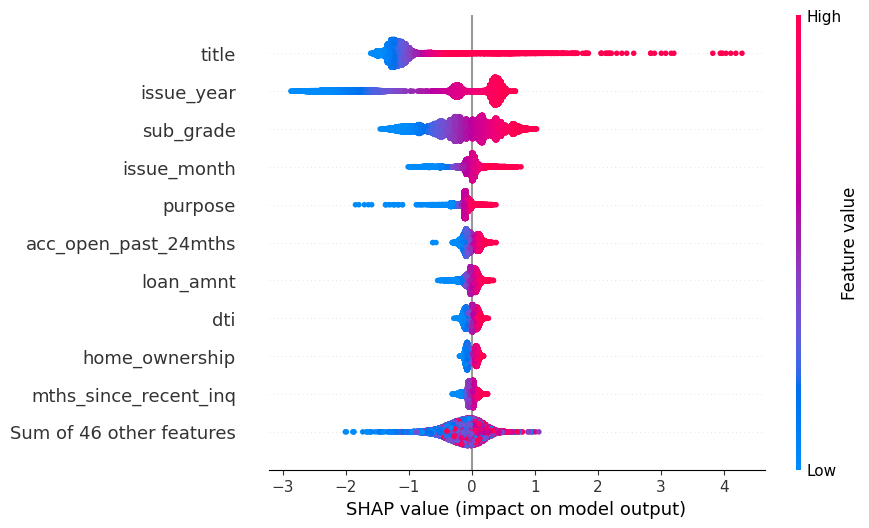

In [78]:
shap.plots.beeswarm(agg_shap_exp, max_display=11)

In [17]:
#shap.s.fplotorce(shap_values[0])

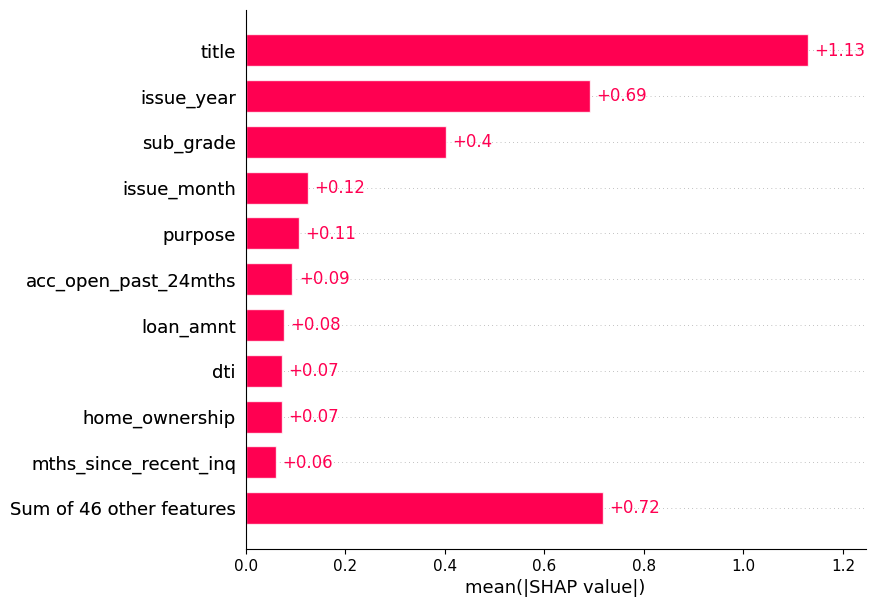

In [80]:
shap.plots.bar(agg_shap_exp, max_display=11)

##### Adding SHAP values to an arbitrary bar chart

In [93]:
# Convert global SHAP values to a DataFrame
shap_df = pd.DataFrame({
    'feature': original_features,
    'shap_values_mean': np.mean(agg_shap_exp.values, axis=0), # mean SHAP (signed)
    'shap_values_abs_mean': np.abs(np.mean(agg_shap_exp.values, axis=0))  # mean absolute SHAP
})

In [101]:
shap_df.sort_values('shap_values_abs_mean', ascending=False).head(1)

,feature,shap_values_mean,shap_values_abs_mean
7,dti,-1.095914,1.095914


In [95]:
# Sort by absolute SHAP value
shap_top10 = shap_df.sort_values('shap_values_abs_mean', ascending=False).head(10)
shap_top10.to_csv('intermediate_output/XAI top 10 features/XGBoost_shap_global_top10.csv',index=False)

In [96]:
def plot_bar_customer(column_to_plot):
    # shap_top10 should have columns: 'feature' and 'shap_value' (signed)
    # Sort to have the largest absolute SHAP values on top
    shap_values_top10 = shap_top10.reindex(shap_top10[column_to_plot].abs().sort_values(ascending=False).index)
    
    plt.figure(figsize=(10, 6))
    
    # Plot horizontal bars
    bars = plt.barh(shap_values_top10['feature'], shap_values_top10[column_to_plot], color='teal')
    plt.gca().invert_yaxis()  # largest on top
    plt.xlabel("SHAP Value")
    plt.title("Top 10 Feature Contributions - ANN (Global SHAP)")
    
    # Add SHAP value labels from the DataFrame (signed values)
    for i, bar in enumerate(bars):
        value = shap_top10[column_to_plot].iloc[i]
        plt.text(value + 0.001 if value > 0 else value - 0.001,
                 bar.get_y() + bar.get_height()/2,
                 f'{value:.3f}', va='center')
    
    plt.tight_layout()
    plt.show()

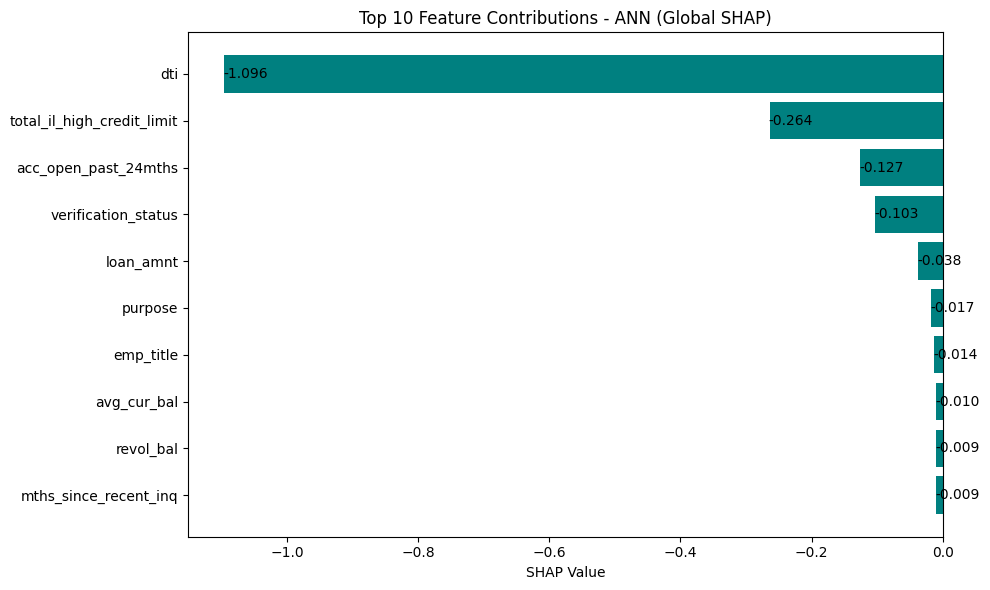

In [97]:
plot_bar_customer('shap_values_mean')

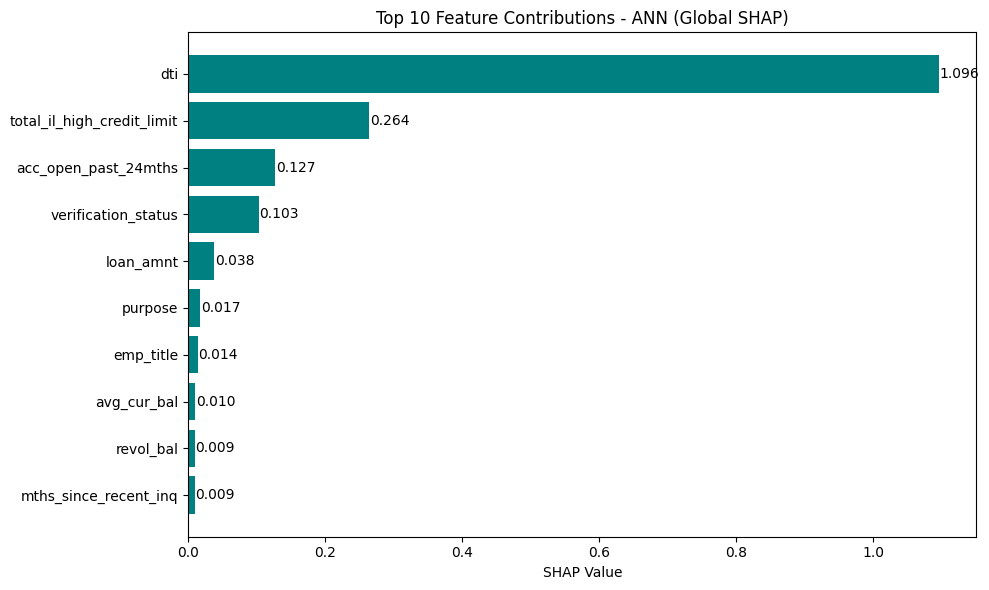

In [98]:
plot_bar_customer('shap_values_abs_mean')

#### 5.5 Applying Submodular Pick (SP)-LIME to the XGBoost Model
* E1B. Thesis - Test different XAI methods with the XGBoost Model (SP-LIME)
* This is a variant of LIME

In [25]:
import lime
import lime.lime_tabular
from lime import submodular_pick

In [26]:
feature_names = X_test.columns.tolist()

In [27]:
len(X_test)

45214

In [28]:
sample_size = 100 #int(round(len(X_test)*0.1))
num_exps_desired = 5

In [29]:
sample_size

100

In [30]:
from contextlib import contextmanager
import sys, os

@contextmanager
def suppress_stdout_stderr():
    # Suppress stdout and stderr
    with open(os.devnull, "w") as devnull:
        old_stdout, old_stderr = sys.stdout, sys.stderr
        sys.stdout, sys.stderr = devnull, devnull
        try:
            yield
        finally:
            sys.stdout, sys.stderr = old_stdout, old_stderr

In [31]:
start_time = time.time()

In [32]:
lime_explainer = lime.lime_tabular.LimeTabularExplainer(
    training_data=X_test.values,
    feature_names=feature_names,
    class_names=["non-default", "default"],
    mode='classification',
    verbose=True,
    random_state = 1
)

In [33]:
# Define the prediction function
predict_fn = lambda x: xgb.predict_proba(x).astype(float)

In [34]:
# Initialize the SubmodularPick object
with suppress_stdout_stderr():
    sp_obj = submodular_pick.SubmodularPick(
        lime_explainer,
        X_test.values,
        predict_fn,
        sample_size=sample_size,
        num_features=10,
        num_exps_desired=num_exps_desired
    )

In [35]:
end_time = time.time()
explanation_time = end_time - start_time
print(f"SP-LIME on XGBoost (Explanation Time): {explanation_time:.2f} seconds")

SP-LIME on XGBoost (Explanation Time): 62.70 seconds


In [36]:
selected_explanations = sp_obj.explanations[:num_exps_desired]

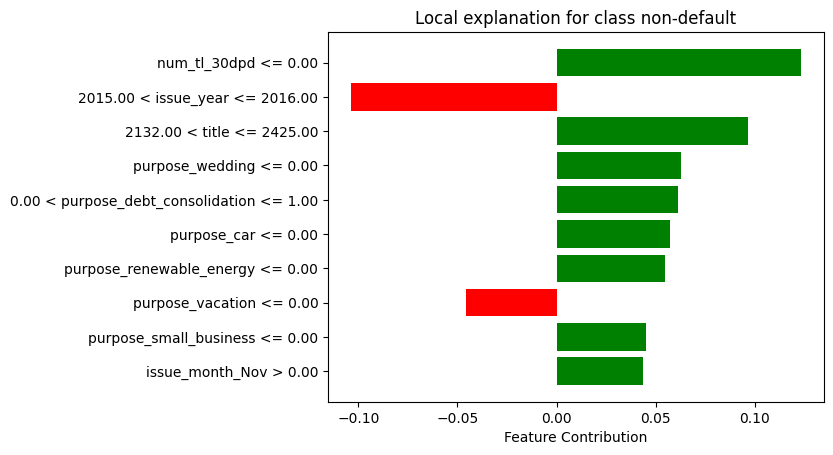

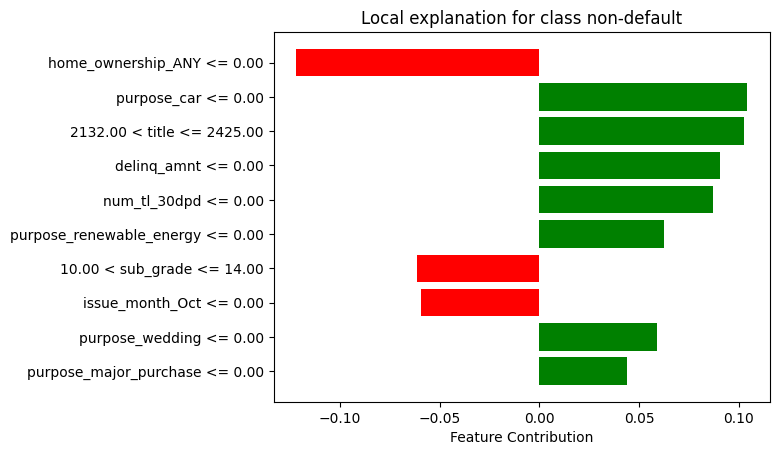

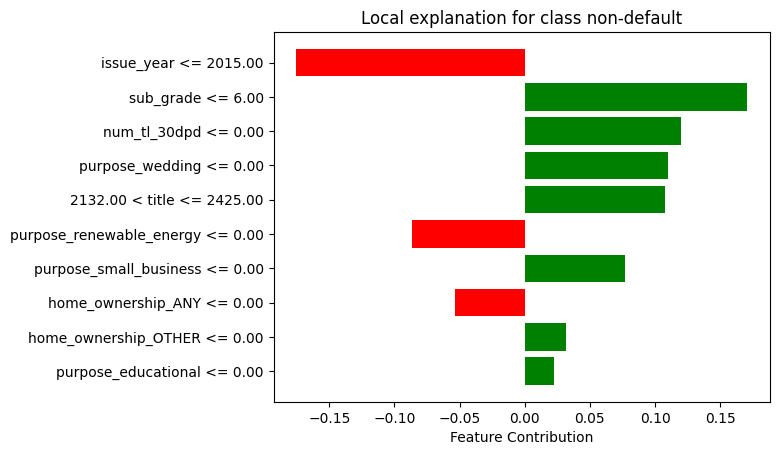

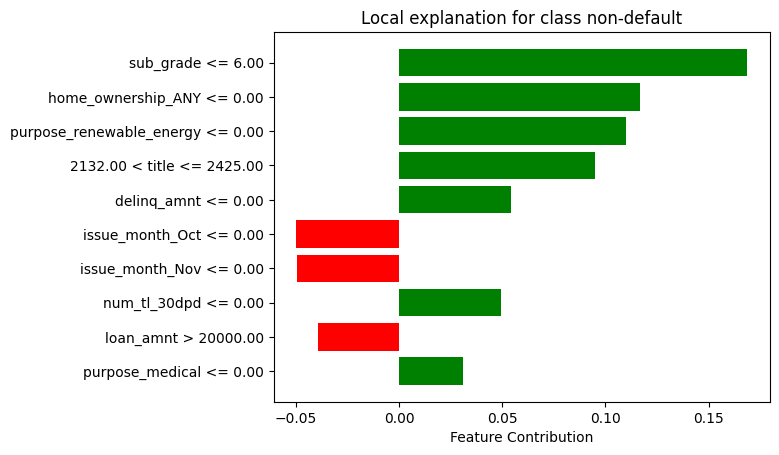

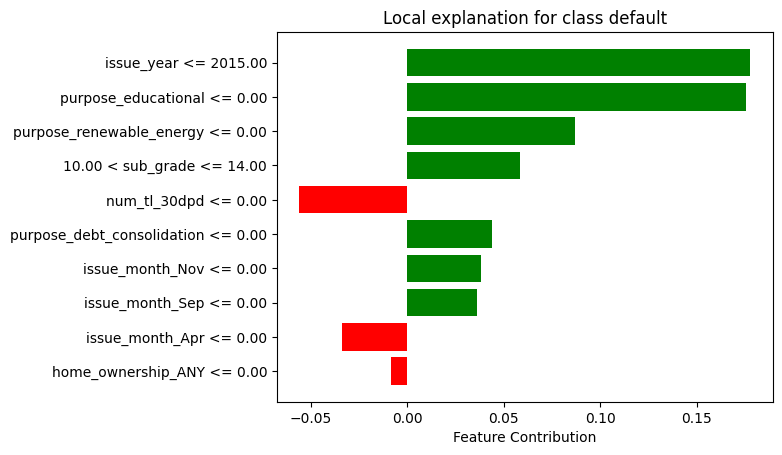

In [37]:
for exp in selected_explanations:
    predicted_class = list(exp.local_exp.keys())[0]
    fig = exp.as_pyplot_figure(label=predicted_class)
    # Label the x-axis
    plt.xlabel("Feature Contribution")
    plt.show()

#### Obtaining average of the 5 results

In [38]:
# Step 1: Collect contributions into a DataFrame
all_contribs = []

for exp in selected_explanations:
    # Take the predicted class for this instance
    predicted_class = list(exp.local_exp.keys())[0]
    
    # Convert list of (feature_index, contribution) to dict: {feature_name: contribution}
    contrib_dict = dict(exp.local_exp[predicted_class])
    
    # Optionally, convert feature indices to feature names
    feature_names = [exp.domain_mapper.feature_names[i] for i in contrib_dict.keys()]
    contrib_dict_named = {name: contrib_dict[i] for i, name in zip(contrib_dict.keys(), feature_names)}
    
    all_contribs.append(contrib_dict_named)

# Step 2: Convert list of dicts to DataFrame
df = pd.DataFrame(all_contribs).fillna(0)  # fill missing features with 0

# Step 3: Compute average contribution for each feature
average_amounts = df.mean(axis=0).sort_values(ascending=False)

df_avg = (
    df.mean(axis=0)
      .sort_values(ascending=False)
      .to_frame(name="average_contribution")
).reset_index().rename(columns={'index':'feature'})

In [39]:
# Display top 10 features
top10_df = df_avg.head(10)
top10_df.to_csv('intermediate_output/XAI top 10 features/XGBoost_splime_top10.csv',index=False)
top10_df

,feature,average_contribution
0,title,0.080285
1,sub_grade,0.067273
2,num_tl_30dpd,0.064784
3,purpose_wedding,0.046301
4,purpose_renewable_energy,0.045516
5,purpose_educational,0.039514
6,purpose_car,0.032263
7,delinq_amnt,0.029005
8,purpose_small_business,0.024320
9,purpose_debt_consolidation,0.021054


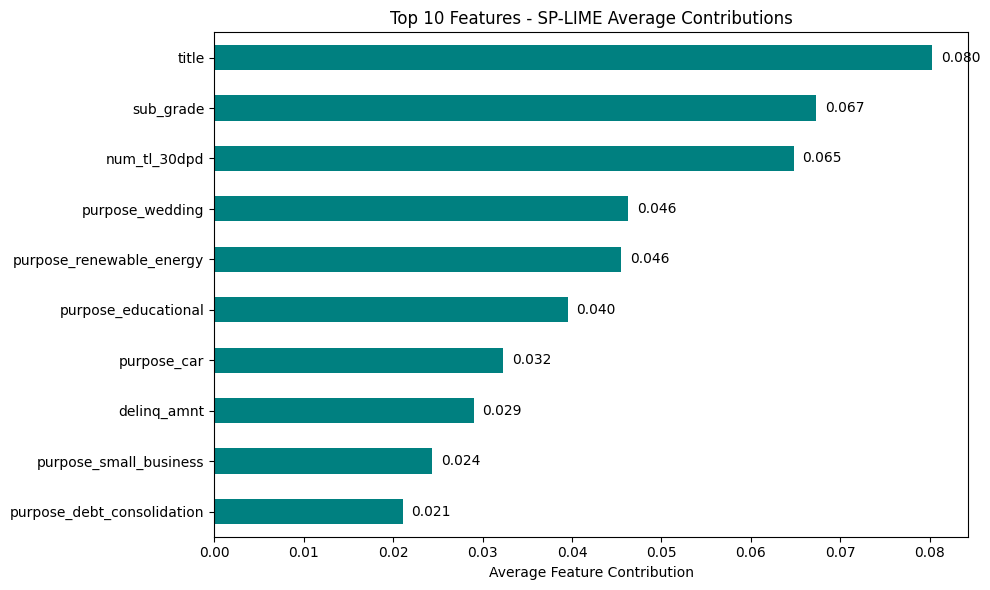

In [40]:
# Visualization - horizontal bar plot with labels
top10_average = average_amounts.head(10)
plt.figure(figsize=(10,6))
ax = top10_average.plot(kind='barh', color='teal')
plt.gca().invert_yaxis()  # largest on top
plt.xlabel("Average Feature Contribution")
plt.title("Top 10 Features - SP-LIME Average Contributions")

# Add text labels
for i, v in enumerate(top10_average):
    ax.text(v + 0.001 if v > 0 else v - 0.001, i, f"{v:.3f}", va='center')

plt.tight_layout()
plt.show()

#### 5.6 Applying Permutation Importance to the XGBoost Model

In [41]:
from sklearn.inspection import permutation_importance

In [42]:
start_time = time.time()

In [43]:
# Compute permutation importance
result = permutation_importance(
    xgb, X_test, y_test,
    n_repeats=5, random_state=1, scoring='roc_auc'
)

In [44]:
end_time = time.time()
explanation_time = end_time - start_time
print(f"Permutation Important on XGBoost (Explanation Time): {explanation_time:.2f} seconds")

Permutation Important on XGBoost (Explanation Time): 62.89 seconds


In [45]:
# Store results in DataFrame
pi_df = pd.DataFrame({
    'feature': X_test.columns,
    'importance_mean': result.importances_mean,
    'importance_std': result.importances_std
}).sort_values(by='importance_mean', ascending=False)

In [46]:
pi_df.head(10)

,feature,importance_mean,importance_std
55,issue_year,0.126500,0.002490
96,sub_grade,0.071063,0.001314
99,title,0.013565,0.000839
56,loan_amnt,0.004520,0.000565
0,acc_open_past_24mths,0.004332,0.000328
8,dti,0.002550,0.000402
100,tot_hi_cred_lim,0.002104,0.000223
1,annual_inc,0.001809,0.000212
39,home_ownership_RENT,0.001675,0.000162
58,mo_sin_old_rev_tl_op,0.001571,0.000149


In [47]:
# Plot top 10 features with labels
top_n = 10
features = pi_df['feature'].head(top_n)[::-1]
importances = pi_df['importance_mean'].head(top_n)[::-1]
pi_df.head(top_n).to_csv('intermediate_output/XAI top 10 features/XGBoost_permutation_importance_top10.csv',index=False)

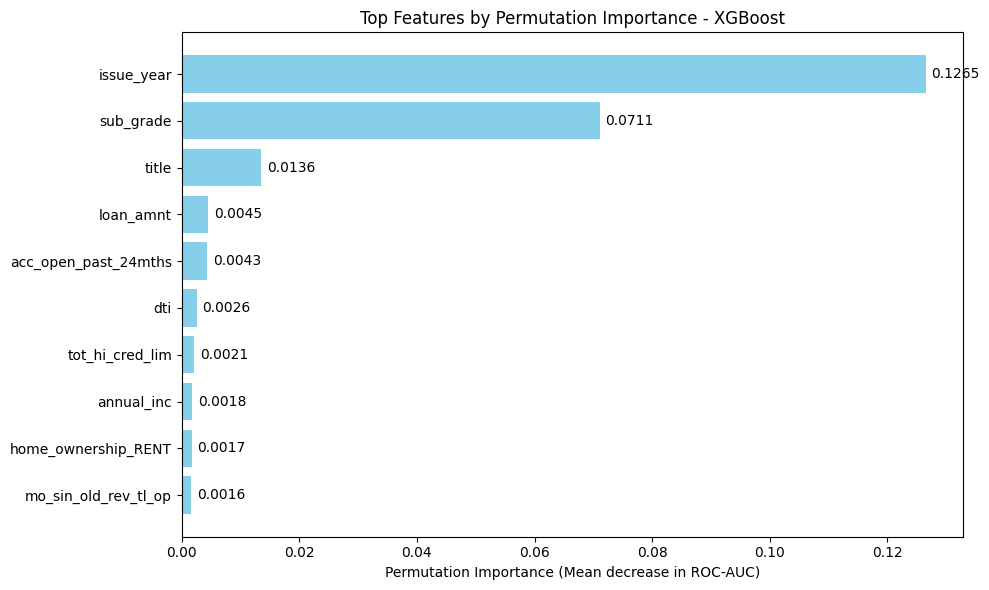

In [48]:
plt.figure(figsize=(10,6))
bars = plt.barh(features, importances, color='skyblue')
plt.xlabel("Permutation Importance (Mean decrease in ROC-AUC)")
plt.title("Top Features by Permutation Importance - XGBoost")

# Add labels on bars
for bar in bars:
    width = bar.get_width()
    plt.text(width + 0.001, bar.get_y() + bar.get_height()/2, f"{width:.4f}", va='center')

plt.tight_layout()
plt.show()